# Cancer Classification - Training Pipeline
This notebook handles the full training lifecycle, from data loading to ensemble evaluation. All logs are streamed back to the local terminal via the Cancer-ML-Bridge.

In [4]:
import requests
import datetime
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# PASTE YOUR TUNNEL URL HERE
LOGGER_URL = "https://adopted-candidates-modes-utils.trycloudflare.com"

def rprint(msg):
    try:
        requests.post(f"{LOGGER_URL}/log", json={
            "time": datetime.datetime.now().strftime("%H:%M:%S"),
            "msg": str(msg)
        }, timeout=2)
    except:
        pass
    print(msg)

rprint("Bridge established! Starting training sequence...")

Bridge established! Starting training sequence...


In [5]:
rprint("--- Step 1: Loading Data ---")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

rprint("--- Step 2: Preprocessing ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rprint(f"Data Split Complete. Train: {len(X_train_scaled)}, Test: {len(X_test_scaled)}")

results_log = []

--- Step 1: Loading Data ---
--- Step 2: Preprocessing ---
Data Split Complete. Train: 455, Test: 114


In [6]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    rprint(f"\nMODEL: {model_name}")
    rprint(f"Accuracy: {report['accuracy']:.4f}")
    rprint(f"Recall (Malignant): {report['0']['recall']:.4f}")
    rprint(f"Precision (Malignant): {report['0']['precision']:.4f}")
    rprint(f"AUC-ROC: {auc:.4f}")
    
    results_log.append({
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Recall_Malignant': report['0']['recall'],
        'Precision_Malignant': report['0']['precision'],
        'AUC_ROC': auc
    })
    return report

In [7]:
rprint("--- Step 3: SVM Training ---")
svm_params = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1], 'kernel': ['rbf']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_grid = GridSearchCV(SVC(probability=True, class_weight='balanced'), svm_params, cv=cv, scoring='recall', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

rprint(f"Best SVM Params: {svm_grid.best_params_}")
best_svm = svm_grid.best_estimator_
evaluate_model(best_svm, X_test_scaled, y_test, "SVM Tuned")

--- Step 3: SVM Training ---
Best SVM Params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

MODEL: SVM Tuned
Accuracy: 0.9649
Recall (Malignant): 0.9762
Precision (Malignant): 0.9318
AUC-ROC: 0.9957


{'0': {'precision': 0.9318181818181818,
  'recall': 0.9761904761904762,
  'f1-score': 0.9534883720930233,
  'support': 42.0},
 '1': {'precision': 0.9857142857142858,
  'recall': 0.9583333333333334,
  'f1-score': 0.971830985915493,
  'support': 72.0},
 'accuracy': 0.9649122807017544,
 'macro avg': {'precision': 0.9587662337662337,
  'recall': 0.9672619047619048,
  'f1-score': 0.9626596790042581,
  'support': 114.0},
 'weighted avg': {'precision': 0.9658578263841422,
  'recall': 0.9649122807017544,
  'f1-score': 0.9650731808230041,
  'support': 114.0}}

In [8]:
rprint("--- Step 4: Random Forest Training ---")
rf_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42), rf_params, cv=cv, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

rprint(f"Best RF Params: {rf_grid.best_params_}")
best_rf = rf_grid.best_estimator_
evaluate_model(best_rf, X_test_scaled, y_test, "Random Forest Tuned")

--- Step 4: Random Forest Training ---
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

MODEL: Random Forest Tuned
Accuracy: 0.9474
Recall (Malignant): 0.9286
Precision (Malignant): 0.9286
AUC-ROC: 0.9940


{'0': {'precision': 0.9285714285714286,
  'recall': 0.9285714285714286,
  'f1-score': 0.9285714285714286,
  'support': 42.0},
 '1': {'precision': 0.9583333333333334,
  'recall': 0.9583333333333334,
  'f1-score': 0.9583333333333334,
  'support': 72.0},
 'accuracy': 0.9473684210526315,
 'macro avg': {'precision': 0.9434523809523809,
  'recall': 0.9434523809523809,
  'f1-score': 0.9434523809523809,
  'support': 114.0},
 'weighted avg': {'precision': 0.9473684210526315,
  'recall': 0.9473684210526315,
  'f1-score': 0.9473684210526315,
  'support': 114.0}}

In [9]:
rprint("--- Step 5: XGBoost Training ---")
xgb_params = {'learning_rate': [0.01, 0.1, 0.2], 'n_estimators': [100, 200], 'max_depth': [3, 5, 7]}
xgb_grid = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), xgb_params, cv=cv, scoring='recall', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

rprint(f"Best XGB Params: {xgb_grid.best_params_}")
best_xgb = xgb_grid.best_estimator_
evaluate_model(best_xgb, X_test_scaled, y_test, "XGBoost Tuned")

--- Step 5: XGBoost Training ---
Best XGB Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}

MODEL: XGBoost Tuned
Accuracy: 0.9298
Recall (Malignant): 0.9286
Precision (Malignant): 0.8864
AUC-ROC: 0.9868


{'0': {'precision': 0.8863636363636364,
  'recall': 0.9285714285714286,
  'f1-score': 0.9069767441860465,
  'support': 42.0},
 '1': {'precision': 0.9571428571428572,
  'recall': 0.9305555555555556,
  'f1-score': 0.9436619718309859,
  'support': 72.0},
 'accuracy': 0.9298245614035088,
 'macro avg': {'precision': 0.9217532467532468,
  'recall': 0.9295634920634921,
  'f1-score': 0.9253193580085162,
  'support': 114.0},
 'weighted avg': {'precision': 0.9310663021189336,
  'recall': 0.9298245614035088,
  'f1-score': 0.9301463616460083,
  'support': 114.0}}

In [10]:
rprint("--- Step 6: ANN Training ---")
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_ann():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(30,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

ann = build_ann()
history = ann.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0,
                  callbacks=[callbacks.EarlyStopping(monitor='val_recall', patience=10, mode='max', restore_best_weights=True)])

class ANNWrapper:
    def __init__(self, model): self.model = model
    def predict(self, X): return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    def predict_proba(self, X): 
        p = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1-p, p])

evaluate_model(ANNWrapper(ann), X_test_scaled, y_test, "ANN")

--- Step 6: ANN Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



MODEL: ANN
Accuracy: 0.9561
Recall (Malignant): 0.9286
Precision (Malignant): 0.9512
AUC-ROC: 0.9940


{'0': {'precision': 0.9512195121951219,
  'recall': 0.9285714285714286,
  'f1-score': 0.9397590361445783,
  'support': 42.0},
 '1': {'precision': 0.958904109589041,
  'recall': 0.9722222222222222,
  'f1-score': 0.9655172413793104,
  'support': 72.0},
 'accuracy': 0.956140350877193,
 'macro avg': {'precision': 0.9550618108920814,
  'recall': 0.9503968253968254,
  'f1-score': 0.9526381387619444,
  'support': 114.0},
 'weighted avg': {'precision': 0.9560729421281235,
  'recall': 0.956140350877193,
  'f1-score': 0.9560273762928302,
  'support': 114.0}}

In [11]:
rprint("--- Step 7: Ensembles ---")

# 1. Soft Voting
voting = VotingClassifier(estimators=[('svm', best_svm), ('rf', best_rf), ('xgb', best_xgb)], voting='soft')
voting.fit(X_train_scaled, y_train)
evaluate_model(voting, X_test_scaled, y_test, "Voting Ensemble")

# 2. Stacking
stacking = StackingClassifier(estimators=[('svm', best_svm), ('rf', best_rf), ('xgb', best_xgb)], final_estimator=LogisticRegression(class_weight='balanced'))
stacking.fit(X_train_scaled, y_train)
evaluate_model(stacking, X_test_scaled, y_test, "Stacking Ensemble")

--- Step 7: Ensembles ---

MODEL: Voting Ensemble
Accuracy: 0.9474
Recall (Malignant): 0.9286
Precision (Malignant): 0.9286
AUC-ROC: 0.9950

MODEL: Stacking Ensemble
Accuracy: 0.9649
Recall (Malignant): 0.9762
Precision (Malignant): 0.9318
AUC-ROC: 0.9960


{'0': {'precision': 0.9318181818181818,
  'recall': 0.9761904761904762,
  'f1-score': 0.9534883720930233,
  'support': 42.0},
 '1': {'precision': 0.9857142857142858,
  'recall': 0.9583333333333334,
  'f1-score': 0.971830985915493,
  'support': 72.0},
 'accuracy': 0.9649122807017544,
 'macro avg': {'precision': 0.9587662337662337,
  'recall': 0.9672619047619048,
  'f1-score': 0.9626596790042581,
  'support': 114.0},
 'weighted avg': {'precision': 0.9658578263841422,
  'recall': 0.9649122807017544,
  'f1-score': 0.9650731808230041,
  'support': 114.0}}

In [12]:
rprint("--- FINAL RESULTS COMPILATION ---")
df_results = pd.DataFrame(results_log).sort_values('Recall_Malignant', ascending=False)
rprint(df_results.to_string(index=False))

winner = df_results.iloc[0]['Model']
rprint(f"\nWINNER: {winner} with Recall: {df_results.iloc[0]['Recall_Malignant']:.4f}")

--- FINAL RESULTS COMPILATION ---
              Model  Accuracy  Recall_Malignant  Precision_Malignant  AUC_ROC
          SVM Tuned  0.964912          0.976190             0.931818 0.995701
  Stacking Ensemble  0.964912          0.976190             0.931818 0.996032
Random Forest Tuned  0.947368          0.928571             0.928571 0.994048
      XGBoost Tuned  0.929825          0.928571             0.886364 0.986772
                ANN  0.956140          0.928571             0.951220 0.994048
    Voting Ensemble  0.947368          0.928571             0.928571 0.995040

WINNER: SVM Tuned with Recall: 0.9762


In [13]:
import shap
import joblib
from google.colab import files

rprint("--- Phase 5: SHAP Explainability (SVM) ---")

# SVM needs a probability-based explainer (KernelExplainer)
# We use a small subset of the training data as a background for speed
background = shap.sample(X_train_scaled, 50)
explainer = shap.KernelExplainer(best_svm.predict_proba, background)
shap_values = explainer.shap_values(X_test_scaled[:50]) # Explaining first 50 test samples

# Generate Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[0], X_test_scaled[:50], feature_names=data.feature_names, show=False)
plt.savefig('shap_summary_svm.png', dpi=150)
rprint("SHAP Plot generated: shap_summary_svm.png")

# Save and Download
joblib.dump(best_svm, 'svm_tuned.pkl')
rprint("Model saved. Downloading now...")
files.download('svm_tuned.pkl')
files.download('shap_summary_svm.png')


--- Phase 5: SHAP Explainability (SVM) ---


  0%|          | 0/50 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>

In [14]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from google.colab import files

rprint("--- Phase 5: SHAP Explainability (SVM) - Fixed ---")

# Sample background for KernelExplainer
background = shap.sample(X_train_scaled, 50)
explainer = shap.KernelExplainer(best_svm.predict_proba, background)

# Explaining a small subset for speed
X_subset = X_test_scaled[:40] 
shap_values = explainer.shap_values(X_subset)

# Handle different SHAP output formats (List vs Array)
# For binary classification, we want the SHAP values for the Malignant class (index 0)
if isinstance(shap_values, list):
    # KernelExplainer usually returns a list [class0_values, class1_values]
    final_shap_values = shap_values[0]
elif len(shap_values.shape) == 3:
    # Some versions return a 3D array (classes, samples, features)
    final_shap_values = shap_values[0]
else:
    # Already a 2D array
    final_shap_values = shap_values

# Generate Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    final_shap_values, 
    X_subset, 
    feature_names=data.feature_names, 
    show=False
)
plt.tight_layout()
plt.savefig('shap_summary_svm.png', dpi=150)
plt.show()

rprint("SHAP Plot generated successfully!")

# Save and Download
joblib.dump(best_svm, 'svm_tuned.pkl')
files.download('svm_tuned.pkl')
files.download('shap_summary_svm.png')


--- Phase 5: SHAP Explainability (SVM) - Fixed ---


  0%|          | 0/40 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x800 with 0 Axes>

In [15]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from google.colab import files

rprint("--- Phase 5: SHAP Debug & Plot ---")

# Sample background
background = shap.sample(X_train_scaled, 50)

# Use a lambda to ensure SHAP sees a clean function
predict_fn = lambda x: best_svm.predict_proba(x)
explainer = shap.KernelExplainer(predict_fn, background)

# Explaining a subset
X_subset = X_test_scaled[:30] 
shap_values = explainer.shap_values(X_subset)

# DEBUG: Log shapes to your local terminal
rprint(f"DEBUG: X_subset shape: {X_subset.shape}")
rprint(f"DEBUG: SHAP type: {type(shap_values)}")

if isinstance(shap_values, list):
    rprint(f"DEBUG: SHAP is list of length {len(shap_values)}")
    for i, arr in enumerate(shap_values):
        rprint(f"DEBUG: Array {i} shape: {arr.shape}")
    # Use the first class (Malignant)
    final_values = shap_values[0]
else:
    rprint(f"DEBUG: SHAP array shape: {shap_values.shape}")
    final_values = shap_values

# FINAL ATTEMPT: Force matching shapes for the plot
if len(final_values.shape) == 3: # Handle (N, features, 1) or similar
    final_values = final_values.reshape(final_values.shape[0], final_values.shape[1])

rprint(f"DEBUG: Final Plotting Shape: {final_values.shape}")

# Create Plot
plt.figure(figsize=(10, 8))
try:
    # We use the legacy summary_plot but explicitly pass the 2D matrix
    shap.summary_plot(final_values, X_subset, feature_names=data.feature_names, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary_svm.png', dpi=150)
    plt.show()
    rprint("SUCCESS: SHAP Plot generated!")
except Exception as e:
    rprint(f"ERROR: Plotting failed with: {str(e)}")

# Save and Download anyway so we don't lose the model
joblib.dump(best_svm, 'svm_tuned.pkl')
files.download('svm_tuned.pkl')


--- Phase 5: SHAP Debug & Plot ---


  0%|          | 0/30 [00:00<?, ?it/s]

DEBUG: X_subset shape: (30, 30)
DEBUG: SHAP type: <class 'numpy.ndarray'>
DEBUG: SHAP array shape: (30, 30, 2)


ValueError: cannot reshape array of size 1800 into shape (30,30)

--- Phase 5: SHAP Final Slicing ---


  0%|          | 0/40 [00:00<?, ?it/s]

Plotting with fixed shape: (40, 30)


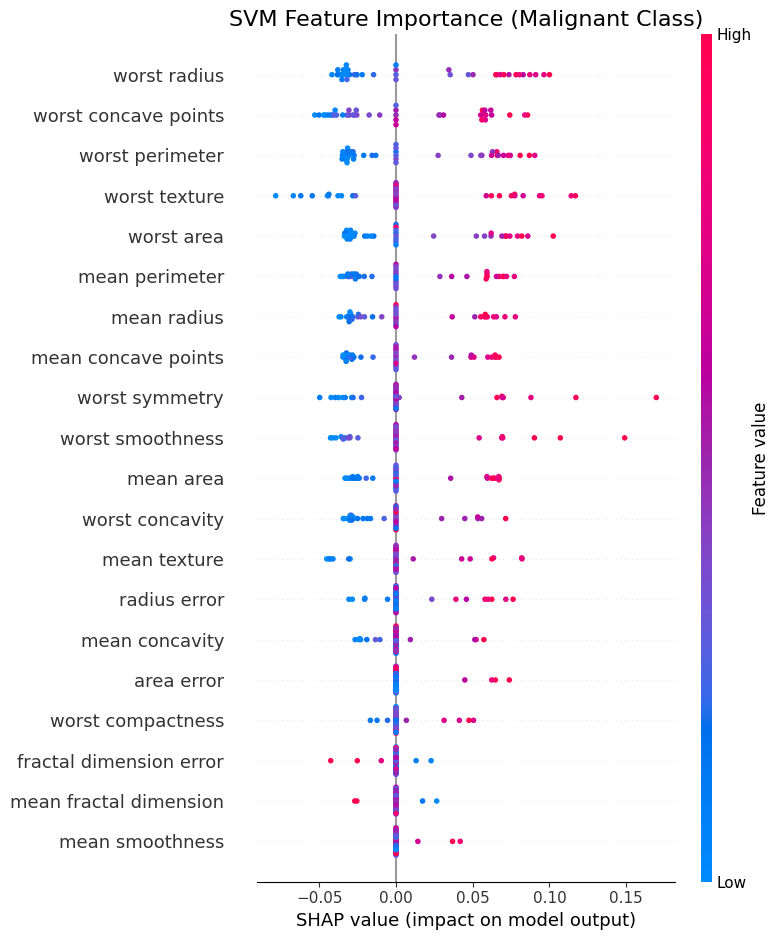

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SUCCESS: Model and SHAP plot are ready for download!


In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from google.colab import files

rprint("--- Phase 5: SHAP Final Slicing ---")

# Setup
background = shap.sample(X_train_scaled, 50)
predict_fn = lambda x: best_svm.predict_proba(x)
explainer = shap.KernelExplainer(predict_fn, background)

# Generate SHAP values (using 40 samples for better visualization)
X_subset = X_test_scaled[:40] 
shap_values = explainer.shap_values(X_subset)

# THE FIX: Slice the 3D array to get (samples, features) for class 0 (Malignant)
# Based on your log (30, 30, 2), we take [:, :, 0]
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    final_shap_values = shap_values[:, :, 0]
elif isinstance(shap_values, list):
    final_shap_values = shap_values[0]
else:
    final_shap_values = shap_values

rprint(f"Plotting with fixed shape: {final_shap_values.shape}")

# Generate Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    final_shap_values, 
    X_subset, 
    feature_names=data.feature_names, 
    show=False
)
plt.title("SVM Feature Importance (Malignant Class)", fontsize=16)
plt.tight_layout()
plt.savefig('shap_summary_svm.png', dpi=150)
plt.show()

# Final Download
joblib.dump(best_svm, 'svm_tuned.pkl')
files.download('svm_tuned.pkl')
files.download('shap_summary_svm.png')
rprint("SUCCESS: Model and SHAP plot are ready for download!")


In [17]:
from google.colab import files
import joblib

# Ensure the model is saved to the Colab disk
joblib.dump(best_svm, 'svm_tuned.pkl')

rprint("Starting model download...")
files.download('svm_tuned.pkl')


Starting model download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>